# 39 — Feature Importance and Save Model

## Goal
To identify useful features and save the trained model for reuse.

## Research Question
Which sensor features helped the model most, and how can we reuse the trained model?

## Why feature importance matters

Feature importance helps explain what the Random Forest used most when making predictions.

In [1]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
ML_READY_PATH = PROCESSED_DIR / "motionsense_ml_ready.csv"

import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv(ML_READY_PATH)
feature_columns = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "acc_magnitude", "gyro_magnitude"
]
X = df[feature_columns]
y = df["activity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Store feature importance values in a Pandas Series.
importance = pd.Series(
    model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

importance

acc_z             0.184807
acc_magnitude     0.166185
gyro_magnitude    0.160347
gyro_x            0.142317
acc_x             0.103480
acc_y             0.095666
gyro_y            0.079744
gyro_z            0.067455
dtype: float64

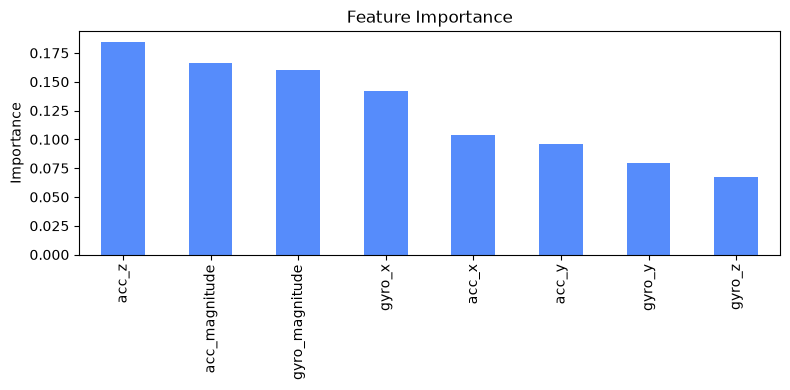

In [2]:
# Plot feature importance.
importance.plot(kind="bar", figsize=(8, 4))
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [3]:
# Save the trained model inside the processed data folder.
MODEL_PATH = PROCESSED_DIR / "motionsense_random_forest_model.joblib"
joblib.dump(model, MODEL_PATH)

print("Model saved to:", MODEL_PATH)

Model saved to: ../data/processed/motionsense_random_forest_model.joblib


In [6]:
# Load the saved model and make one prediction.
loaded_model = joblib.load(MODEL_PATH)

one_sample = X_test.iloc[[0]]
prediction = loaded_model.predict(one_sample)

print("Predicted activity:", prediction[0])
print("Actual activity:", y_test.iloc[0])

Predicted activity: Walking Upstairs
Actual activity: Walking Downstairs


## Key idea

Saving the model means we do not need to train it again every time we want to make predictions.